# **Ievads attēlu apstrādē**

## **Praktiskais darbs Nr. 3**

---

**Students:** Edgars Polis

**Studenta apliecības Nr.:** 241RDB296

**Saite uz programmēšanas kodu:** https://github.com/Edgars-P/RTU_IAA_MD/blob/main/LD3/IAA_LD3.ipynb

---

**Variants 6**

- Sāls un piparu troksnis
- Gausa troksnis


## **Programmas kods ar izvadi**

_Darbā jābūt iekļautam palaistam Python kodam, t. i., kodam jābūt izpildītam tā, lai dokumentā būtu redzamas visas vizualizācijas, attēli, grafiki un cita programmas izvade. Nepalaists kods vai kods bez redzamiem rezultātiem netiks uzskatīts par korekti iesniegtu. Kodam jābūt bez komentāriem._


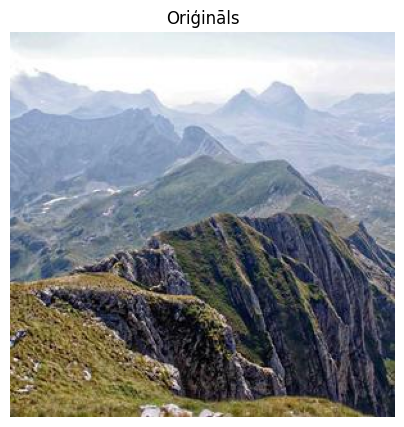

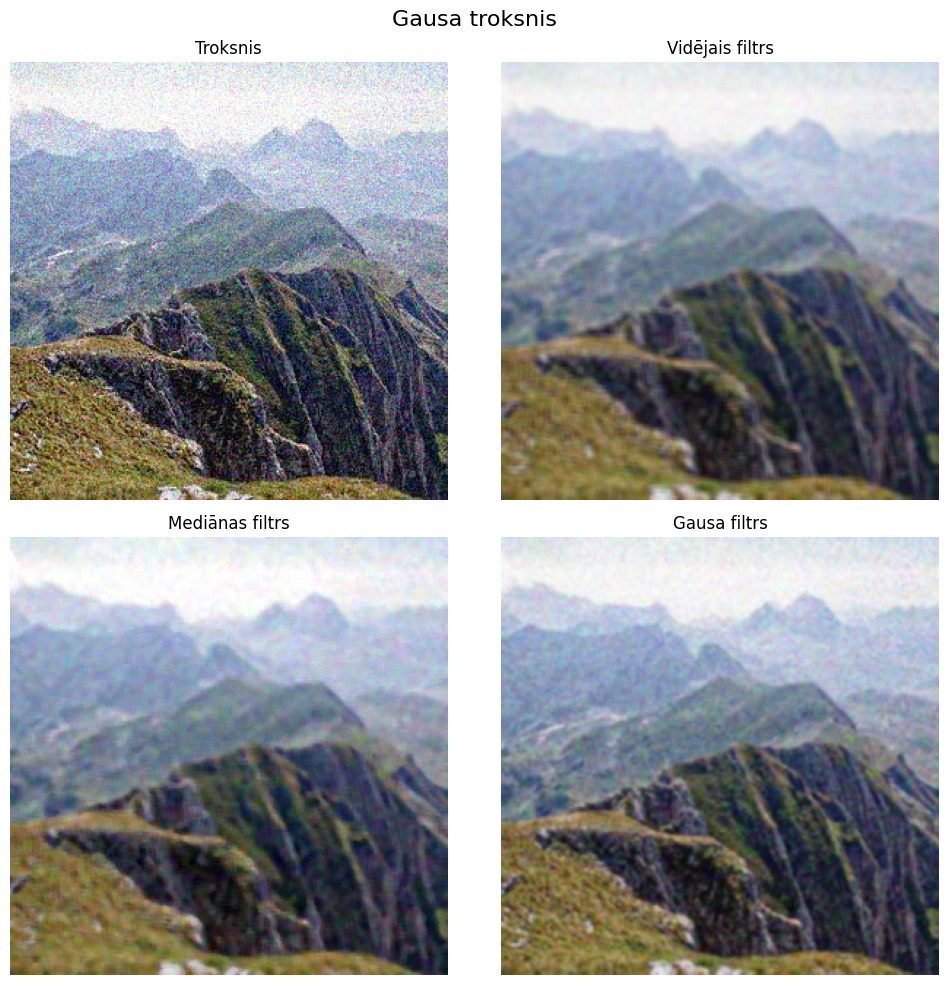

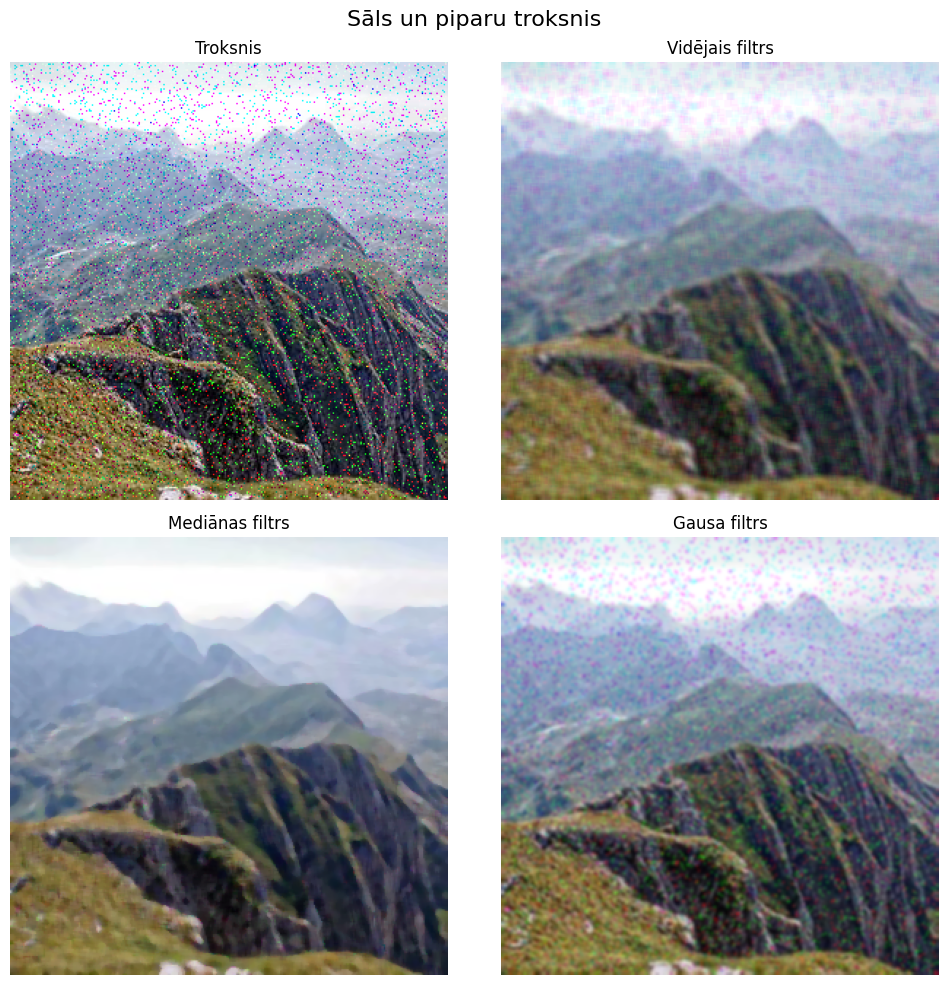

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("./231-300x300.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def add_gaussian_noise(image, sigma=25):
    row, col, ch = image.shape
    gauss = np.random.normal(0, sigma, (row, col, ch))
    noisy = image.astype(np.float32) + gauss
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_and_pepper_noise(image, amount=0.05):
    noisy = np.copy(image)
    num_salt = np.ceil(amount * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[tuple(coords)] = 255
    num_pepper = np.ceil(amount * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[tuple(coords)] = 0
    return noisy

def display_results(noisy, f1, f2, f3, title):
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    images = [noisy, f1, f2, f3]
    labels = ["Troksnis", "Vidējais filtrs", "Mediānas filtrs", "Gausa filtrs"]
    
    for i in range(4):
        row = i // 2
        col = i % 2
        axs[row, col].imshow(images[i])
        axs[row, col].set_title(labels[i])
        axs[row, col].axis("off")
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

gaussian_noisy = add_gaussian_noise(img_rgb)
sp_noisy = add_salt_and_pepper_noise(img_rgb)

plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title("Oriģināls")
plt.axis("off")
plt.show()

g_mean = cv2.blur(gaussian_noisy, (5, 5))
g_median = cv2.medianBlur(gaussian_noisy, 5)
g_gauss = cv2.GaussianBlur(gaussian_noisy, (5, 5), 0)

display_results(gaussian_noisy, g_mean, g_median, g_gauss, "Gausa troksnis")

sp_mean = cv2.blur(sp_noisy, (5, 5))
sp_median = cv2.medianBlur(sp_noisy, 5)
sp_gauss = cv2.GaussianBlur(sp_noisy, (5, 5), 0)

display_results(sp_noisy, sp_mean, sp_median, sp_gauss, "Sāls un piparu troksnis")

# **Secinājumi**

**Kurš filtrs vislabāk noņēma trokšņus?**

Gausa troksni vizuāli vislabāk mazināja vidējais filtrs, bet sāls un piparu troksni visveiksmīgāk novērsa mediānas filtrs.  
Sāls un piparu trokšņa gadījumā iegūtās krāsas un detaļas ir gandrīz identiskas oriģinālajam attēlam, jo mediānas filtrs ignorē atsevišķus ekstrēmus pikseļus.

**Kurš filtrs saglabāja visvairāk detaļu?**

Kopumā visvairāk detaļu saglabā Gausa un mediānas filtri. Novērojot attēla zāli tuvplānā, redzams, ka Gausa filtrs labāk saglabā smalkas detaļas, jo tas tuvākajiem pikseļiem piešķir lielāku svaru.  
Bet kalnos fonā mediānas filtrs saglabā nedaudz asākas un izteiksmīgākas kontūras, neradot tik lielu izplūšanu.

**Kāda bija filtrēšanas efektivitāte katram trokšņa veidam?**

Sāls un piparu troksnis tika perfekti izfiltrēts ar mediānas filtru, bet pārējie filtri iegūst lielākus krāsainus izplūdumus.
Gausa trokšņa filtrēšanas efektivitāte ar visām trim metodēm bija salīdzinoši zema – filtri nespēja noņemt trokšņa veiktās izmaiņas.

**Kur šādas metodes var tikt pielietotas praktiski?**

Šāda veida vienkārša filtrēšana varētu būt noderīga zemas jaudas ierīcēs kur nevar (vai būtu pārāk dārgi) izmantot sarežģītākus algotritmus datu apstrādei (Piemēram, CubeSat satelīts ar kameru un ierobežotu elektrību). Šādas ierīces kamera saņem daudz sāls un piparu veida traucējumus (piem. radīācijas vai kosmiskā starojuma dēļ), izfiltrējot šos dažus pikseļus, bildes uzreiz kļūst vieglāk apstrādājamas un saspiežamas.
